# Separation of multiple inertial particles based on size (each belong to one of the two size classes)

In [1]:
# This notebook contains the julia implementation of separation of multiple inertial particles based on size
# via the viscous streaming phenomenon 
# (refer the paper listed here https://github.com/quasarsrus/Multi-Particle-Transport-Viscous-Streaming-RL/tree/main).

In [2]:
# To download viscous streaming, use the command "Pkg.add(url = "https://github.com/jdeldre/ViscousStreaming.jl").
# Viscous Streaming is an 'older' package. There might be sub-dependencies that have version clashes.
# Preferably, run this on Julia v1.4.2.


using Pkg
using Plots
using ViscousStreaming
using HDF5
using JLD2
using FileIO
using CUDA
using Statistics
using NBInclude
using DataFrames

In [3]:
 Re = 40
 ϵ = 0.1
 Ω = 1.0 # frequency (keep this equal to 1)
 Tp = 2π/Ω # one period of oscillation
 p = StreamingParams(ϵ,Re)

 Tmax = 50*Tp

 Δx = 0.02
 xlim = (-2.8,2.8)
 ylim = (-2.8,2.8)
 n = 75
 body = Circle(0.2,n)

Circular body with 72 points and radius 0.2
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [4]:
# Change these values to increase or decrease the radius (τ) or the mass (β) of
# the inertial particles.

 τ1 = 0.4 # Stokes number, should be small
 β1 = 1.0 # Density parameter. Less than 1 means heavier than fluid.
 p_inert1 = InertialParameters(tau=τ1,beta=β1,epsilon=ϵ,Re=Re)

 τ2 = 0.1 # Stokes number, should be small
 β2 = 1.0 # Density parameter. Less than 1 means heavier than fluid.
 p_inert2 = InertialParameters(tau=τ2,beta=β2,epsilon=ϵ,Re=Re)

InertialParameters(1.0, 0.1, 0.1, 40)

In [5]:
 bl = BodyList()
 bL1 = deepcopy(body)
 bL2 = deepcopy(body)
 bR1 = deepcopy(body)
 bR2 = deepcopy(body)

Circular body with 72 points and radius 0.2
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [6]:
#Square
# left 1 cylinder
cent = (-2.0,2.0)
 α = 0.0
TL1 = RigidTransform(cent,α)
TL1(bL1) # transform the body to the current configuration

# left 2 cylinder
cent = (-2.0,-2.0)
 α = 0.0
TL2 = RigidTransform(cent,α)
TL2(bL2) # transform the body to the current configuration

# right 1 cylinder
cent = (2.0,2.0)
 α = 0.0
TR1 = RigidTransform(cent,α)
TR1(bR1) # transform the body to the current configuration

# right 2 cylinder
cent = (2.0,-2.0)
 α = 0.0
TR2 = RigidTransform(cent,α)
TR2(bR2) # transform the body to the current configuration

push!(bl,bL1);
push!(bl,bL2);
push!(bl,bR1);
push!(bl,bR2);

In [7]:
@time solver2 = FrequencyStreaming(Re,ϵ,Δx,xlim,ylim,bl);

 36.233309 seconds (1.24 G allocations: 54.883 GiB, 10.74% gc time)


In [8]:
# 4-Cylinder

ampvec = [ComplexF64[0.0,0.0] for i in 1:length(bl)];
ampvec[1] = [1,0];  a2 = deepcopy(ampvec);
ampvec[2] = [1,0];  a3 = deepcopy(ampvec); 
ampvec[3] = [1,0];  a4 = deepcopy(ampvec); 
ampvec[4] = [1,0];  a5 = deepcopy(ampvec);
ampvec[1] = [0,0];  a6 = deepcopy(ampvec);
ampvec[2] = [0,0];  a7 = deepcopy(ampvec);
ampvec[3] = [0,0];  a8 = deepcopy(ampvec);
ampvec[2] = [1,0];  a9 = deepcopy(ampvec);
ampvec[1] = [1,0];  a10 = deepcopy(ampvec);
ampvec[2] = [0,0];  a11 = deepcopy(ampvec);
ampvec[3] = [1,0];  a12 = deepcopy(ampvec);
ampvec[4] = [0,0];  a13 = deepcopy(ampvec);
ampvec[1] = [0,0];  a14 = deepcopy(ampvec);
ampvec[2] = [1,0];  a15 = deepcopy(ampvec);
ampvec[3] = [0,0];  a16 = deepcopy(ampvec);

actionspace = [a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12, a13, a14, a15, a16];

In [9]:
strdVuxy1 = []
strdVvxy1 = []
for i = 1: length(actionspace)
    soln = solver2(actionspace[i],bl);
    isoln = inertial_velocity(soln,p_inert1);
    v̄L = lagrangian_mean_velocity(isoln);
    v̄Luxy, v̄Lvxy = interpolatable_field(v̄L,isoln.g);
    push!(strdVuxy1,v̄Luxy)
    push!(strdVvxy1,v̄Lvxy)
end

strdVuxy2 = []
strdVvxy2 = []
for i = 1: length(actionspace)
    soln = solver2(actionspace[i],bl);
    isoln = inertial_velocity(soln,p_inert2);
    v̄L = lagrangian_mean_velocity(isoln);
    v̄Luxy, v̄Lvxy = interpolatable_field(v̄L,isoln.g);
    push!(strdVuxy2,v̄Luxy)
    push!(strdVvxy2,v̄Lvxy)
end

In [10]:
function mean_motion(dR,R,p,t,v̄Luxy,v̄Lvxy)
    dR[1] = v̄Luxy(R[1],R[2])
    dR[2] = v̄Lvxy(R[1],R[2])
   return dR
end

mean_motion (generic function with 1 method)

In [11]:
function sequence(pos)
    if pos[1] >= 0 && pos[2] >= 0
        return [1, 10, 4]
    elseif pos[1] < 0 && pos[2] >= 0
        return [13, 14, 4]
    elseif pos[1] < 0 && pos[2] < 0
        return [7, 10, 4]
    else
        return [15, 14, 4]
    end
end 

function reset_position_collec(n_small_particles)

    positions = Vector{Tuple{Float64,Float64}}(undef, 2*n_small_particles)

    for i in 2:(2*n_small_particles)
        x = trunc(2.4*rand() - 1.2, digits = 5)
        y = trunc(2.4*rand() - 1.2, digits = 5)

        positions[i] = (x,y)
    end

    return positions
end

function reset_position_sep(n_small_particles)

    start_positionx_11 = trunc(3.0*rand() - 1.5, digits = 5)
    start_positiony_11 = trunc(3.0*rand() - 1.5, digits = 5)

    positions = Vector{Tuple{Float64,Float64}}(undef, 2*n_small_particles)

    positions[1] = (start_positionx_11, start_positiony_11)

    for i in 2:(2*n_small_particles)
        x = trunc(start_positionx_11 + 0.1*rand() - 0.05, digits = 5)
        y = trunc(start_positiony_11 + 0.1*rand() - 0.05, digits = 5)

        positions[i] = (x,y)
    end

    return positions
end

reset_position_sep (generic function with 1 method)

In [12]:
@nbinclude("DQN_Partm.ipynb")

Dict{Any,Any} with 8 entries:
  "W2" => [0.019989 0.0733717 … 0.203695 0.0215958; -0.202167 0.205037 … 0.1264…
  "W3" => [-0.0364881 0.151251 … -0.11078 -0.180606; 0.0263421 0.100304 … 0.076…
  "W4" => [-0.101386 0.083399 … -0.206469 0.0411103; -0.130023 0.201294 … -0.10…
  "b3" => [0.0; 0.0; … ; 0.0; 0.0]
  "b4" => [0.0; 0.0; … ; 0.0; 0.0]
  "W1" => [-1.50407 0.867663; 0.576795 -0.824585; … ; 1.22258 0.415165; -1.5265…
  "b2" => [0.0; 0.0; … ; 0.0; 0.0]
  "b1" => [0.0; 0.0; … ; 0.0; 0.0]

In [13]:
nn_param.param_learn = loadmodel("Weights_Partm(Centre)_Diff_bounds")

Dict{Any,Any} with 8 entries:
  "W2" => [-0.138227 -0.186301 … 0.0272445 -0.140838; 0.300678 -0.57134 … 0.556…
  "W3" => [0.109141 1.20805 … -0.573126 0.151999; -0.0129909 0.042542 … 0.42963…
  "W4" => [0.267213 0.239549 … -0.420732 -0.642193; -0.791307 0.209453 … -0.577…
  "b3" => [-0.527819; 0.494328; … ; -0.172566; -0.00230737]
  "b4" => [0.130156; 0.0583249; … ; 0.542886; 0.0662388]
  "W1" => [-0.357431 1.59339; -0.791584 -0.237095; … ; -1.68231 1.44457; 0.3139…
  "b2" => [-0.0214586; -0.111473; … ; 0.698619; 0.713717]
  "b1" => [-2.30053; 1.61034; … ; 0.440515; 1.04874]

In [14]:
function cyl_choice(centroid)
    if centroid[1] >= 0 && centroid[2] >= 0
        return 1
    elseif centroid[1] < 0 && centroid[2] >= 0
        return 13
    elseif centroid[1] < 0 && centroid[2] < 0
        return 7
    else
        return 15
    end
end

cyl_choice (generic function with 1 method)

In [23]:
function particle_collector(positions::Vector{Tuple{Float64,Float64}}, n_small_particles)
    @assert length(positions) == 2*n_small_particles

    done = false

    positions_copy = deepcopy(positions)

    temp_sum = hcat(first.(positions_copy), last.(positions_copy))
    centroid = (sum(temp_sum[:,1]),sum(temp_sum[:,2]))

    part_posx = [Vector{Vector{Float64}}() for _ in 1:2*n_small_particles]
    part_posy = [Vector{Vector{Float64}}() for _ in 1:2*n_small_particles]

    multiplier = 30000

    cyl_act = cyl_choice(centroid)

    #cyl_act = rand([1, 7, 13, 15])
    
    tolerance = 0.001
    
    v̄Lfcn1(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy1[cyl_act], strdVvxy1[cyl_act])
    
    v̄Lfcn2(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy2[cyl_act], strdVvxy2[cyl_act])

    Tmax = multiplier * Tp
    j = 1

    while !done

        flag = false
        #println(j)

        for i in 1:n_small_particles

            sol = compute_trajectory(
                v̄Lfcn1,
                positions_copy[i],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[i], sol[1,:])
            push!(part_posy[i], sol[2,:])

            positions_copy[i] = (last(sol[1,:]), last(sol[2,:]))
        end

        for i in (n_small_particles+1):2*n_small_particles
            sol = compute_trajectory(
                v̄Lfcn2,
                positions_copy[i],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[i], sol[1,:])
            push!(part_posy[i], sol[2,:])

            positions_copy[i] = (last(sol[1,:]), last(sol[2,:]))
        end

        for i in 1:length(positions_copy)-1
            xi, yi = positions_copy[i]
            for j in i+1:length(positions_copy)
                xj, yj = positions_copy[j]
                    if (xi - xj)^2 + (yi - yj)^2 > tolerance
                        done = false
                        flag = true
                    end
            end
        end

        if j > 5
            break
        end

        if !flag
            println(flag)
            done = true
        end
        j+=1
    end
    return positions_copy, cyl_act
end


particle_collector (generic function with 1 method)

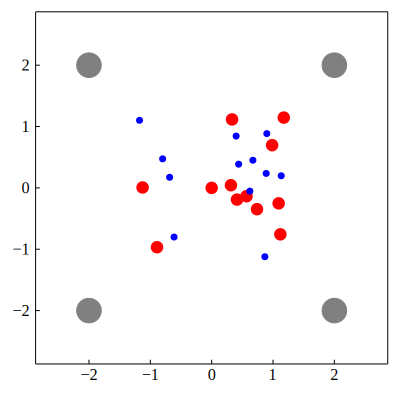

In [27]:
position_list_init = reset_position_collec(12)

n_particles = length(position_list_init)

soln_0 = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)],bl);
#soln_0 = solver2(actionspace[1],bl);


marker_sizes = Array{Float64, 1}(undef, n_particles)
for i in 1:n_particles
    if i <= n_particles/2
        marker_sizes[i] = 7.0
    else
        marker_sizes[i] = 4.0
    end
end

xs = [p[1] for p in position_list_init]
ys = [p[2] for p in position_list_init]

colours = [i <= length(position_list_init)/2 ? :red : :blue for i in 1:length(position_list_init)]

ps = scatter(
    xs, ys,
    markersize = marker_sizes,
    markercolor = colours,
    ratio = 1,
    legend = false,
    linewidth = 2,
    xlim = xlim,
    ylim = ylim,
    tickfont = font(10, "Times"),
    size = (400, 400),
    markerstrokewidth = 0 
)

plot!(ps, lagrangian_mean_streamfunction(soln_0), soln_0.g, levels=15, color=:black, linewidth=0.5)
plot!(ps, bl, fillcolor=:gray, linecolor=:gray)
display(ps)
#savefig(ps, "mpart_sep_two_s_0_1.png")

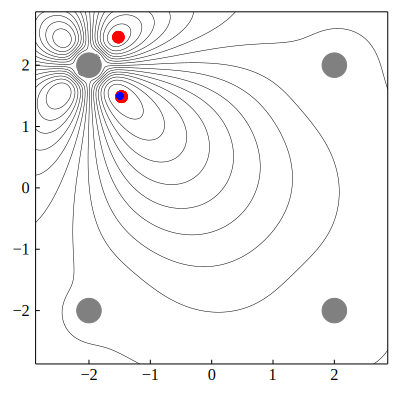

In [29]:
position_list, cyl_act = particle_collector(position_list_init,12)

soln_0 = solver2(actionspace[cyl_act],bl);

xs = [p[1] for p in position_list]
ys = [p[2] for p in position_list]

colours = [i <= length(position_list_init)/2 ? :red : :blue for i in 1:length(position_list_init)]

ps = scatter(
    xs, ys,
    markersize = marker_sizes,
    markercolor = colours,
    ratio = 1,
    legend = false,
    linewidth = 2,
    xlim = xlim,
    ylim = ylim,
    tickfont = font(10, "Times"),
    size = (400, 400),
    markerstrokewidth = 0 
)

#for i in keys(drop_row)
#    scatter!([drop_row[i][1]], [drop_row[i][2]], markersize = 7, markercolor = :red)
#end

plot!(ps, lagrangian_mean_streamfunction(soln_0), soln_0.g, levels=15, color=:black, linewidth=0.5)
plot!(ps, bl, fillcolor=:gray, linecolor=:gray)
display(ps)
#savefig(ps, "mpart_sep_two_s_0_2.png")

In [30]:
counter = 0
drop_row = Dict()
n_small_particles = Int(length(position_list)/2)
n_large_particles = Int(length(position_list)/2)
for i in 1:length(position_list)
    if abs(position_list[i][1]) > 2 || abs(position_list[i][2]) > 2
        counter += 1
        drop_row[i] = (position_list[i][1], position_list[i][2])
        if i <= length(position_list)/2
            n_large_particles-=1
        else
            n_small_particles-=1
        end
    end
end
deleteat!(position_list, sort(collect(keys(drop_row))))
println(counter)
println(drop_row)
println(n_large_particles, " ", n_small_particles)

3
Dict{Any,Any}(2 => (-1.5207064035239866, 2.45667342969192),5 => (-1.5207064035239866, 2.4566734296919197),12 => (-1.520706403523985, 2.4566734296919184))
9 12


In [31]:
position_list

21-element Array{Tuple{Float64,Float64},1}:
 (-1.4694315319747449, 1.4871328918272009)
 (-1.4694315319747464, 1.4871328918272)
 (-1.4694315319747473, 1.4871328918272013)
 (-1.469431531974745, 1.4871328918271995)
 (-1.4694315319747444, 1.4871328918272002)
 (-1.4694315319747446, 1.4871328918272)
 (-1.4694315319747469, 1.4871328918272004)
 (-1.469431531974745, 1.4871328918271995)
 (-1.4694315319747449, 1.4871328918272009)
 (-1.4926241095374528, 1.497641826035013)
 (-1.4926241095374457, 1.4976418260350077)
 (-1.4926241095374457, 1.4976418260350077)
 (-1.4926241095374544, 1.4976418260350157)
 (-1.4926241095374544, 1.4976418260350157)
 (-1.4926241095374413, 1.4976418260350082)
 (-1.4926241095374486, 1.4976418260350226)
 (-1.4926241095374544, 1.4976418260350206)
 (-1.4926241095374486, 1.4976418260350226)
 (-1.4926241095374462, 1.4976418260350215)
 (-1.4926241095374484, 1.4976418260350088)
 (-1.4926241095374484, 1.4976418260350088)

In [32]:
function dqn_transport(position_list, n_large_particles, n_small_particles, drop_row = nothing)

    position_list_copy = deepcopy(position_list)
    total_particles = n_large_particles + n_small_particles


    temp_sum = hcat(first.(position_list_copy), last.(position_list_copy))
    centroid = (sum(temp_sum[:,1])/ total_particles ,sum(temp_sum[:,2])/ total_particles)

    part_posx = [Vector{Vector{Float64}}() for _ in 1:(n_large_particles + n_small_particles)]
    part_posy = [Vector{Vector{Float64}}() for _ in 1:(n_large_particles + n_small_particles)]

    if !isnothing(drop_row)
        drop_part_pos = Vector{Tuple{Float64,Float64}}(undef, length(keys(drop_row)))
        ctr = 1
        for i in keys(drop_row)
            drop_part_pos[ctr] = drop_row[i]
            ctr += 1
        end
        part_posx_dropped = [Vector{Vector{Float64}}() for _ in 1:length(keys(drop_row))]
        part_posy_dropped = [Vector{Vector{Float64}}() for _ in 1:length(keys(drop_row))]
        total_particles_original = total_particles + length(keys(drop_row))
    end
    
    agentdata.epsilon = 1
    multiplier = 15

    Tmax = multiplier * Tp

    for i = 1:100 

        actions,_ = forward_propagation([centroid[1] centroid[2]], nn_param.param_learn, nn_param.activation_type)
        action = argmax(actions)[2]

        v̄Lfcn1(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy1[action], strdVvxy1[action])

        v̄Lfcn2(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy2[action], strdVvxy2[action])
        
        for itr = 1:n_large_particles

            sol_1 = compute_trajectory(
                v̄Lfcn1,
                position_list_copy[itr],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[itr], sol_1[1,:])
            push!(part_posy[itr], sol_1[2,:])

            position_list_copy[itr] = (last(sol_1[1,:]), last(sol_1[2,:]))
        end
        
        for itr = 1:n_small_particles
            sol_2 = compute_trajectory(
                v̄Lfcn2,
                position_list_copy[n_large_particles + itr],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[n_large_particles + itr], sol_2[1,:])
            push!(part_posy[n_large_particles + itr], sol_2[2,:])

            position_list_copy[n_large_particles + itr] = (last(sol_2[1,:]), last(sol_2[2,:]))
        end
        
        if !isnothing(drop_row)
            for (ind_itr, itr) = enumerate(keys(drop_row))
                if itr <= Int(total_particles_original/2)
                    sol_0_1 = compute_trajectory(
                    v̄Lfcn1,
                    drop_part_pos[ind_itr],
                    Tmax,
                    10Tp,
                    bl=bl,
                    ϵ=p.ϵ
                    )

                    push!(part_posx_dropped[ind_itr], sol_0_1[1,:])
                    push!(part_posy_dropped[ind_itr], sol_0_1[2,:])

                    drop_part_pos[ind_itr] = (last(sol_0_1[1,:]), last(sol_0_1[2,:]))
                else
                    sol_0_2 = compute_trajectory(
                    v̄Lfcn2,
                    drop_part_pos[ind_itr],
                    Tmax,
                    10Tp,
                    bl=bl,
                    ϵ=p.ϵ
                    )

                    push!(part_posx_dropped[ind_itr], sol_0_2[1,:])
                    push!(part_posy_dropped[ind_itr], sol_0_2[2,:])

                    drop_part_pos[ind_itr] = (last(sol_0_2[1,:]), last(sol_0_2[2,:]))

                end
            end
        end
        
        temp_sum = hcat(first.(position_list_copy), last.(position_list_copy))
        centroid = (sum(temp_sum[:,1])/ total_particles,sum(temp_sum[:,2])/ total_particles)
    end
    part_pos = collect(zip(part_posx, part_posy))
    if !isnothing(drop_row)
        part_pos_dropped = collect(zip(part_posx_dropped, part_posy_dropped))
        return part_pos, part_pos_dropped
    else
        return part_pos
    end
end


dqn_transport (generic function with 2 methods)

In [ ]:
#dqn_transported_position, dropped_particles = dqn_transport(position_list, n_large_particles, n_small_particles, drop_row)


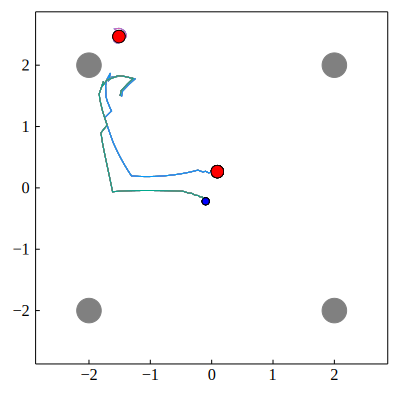

In [33]:
dqn_transported_position, dropped_particles = dqn_transport(position_list, n_large_particles, n_small_particles, drop_row)

soln_0_2 = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)],bl);

px = Vector{Vector{Float64}}(undef, n_large_particles+n_small_particles)
py = Vector{Vector{Float64}}(undef, n_large_particles+n_small_particles)

if !isnothing(drop_row)
    px_d = Vector{Vector{Float64}}(undef, length(keys(drop_row)))
    py_d = Vector{Vector{Float64}}(undef, length(keys(drop_row)))
    marker_sizes_dropped = Array{Float64, 1}(undef, length(keys(drop_row)))
    
    for (i,j) in enumerate(keys(drop_row))
        px_d[i] = reduce(vcat, dropped_particles[i][1])
        py_d[i] = reduce(vcat, dropped_particles[i][2])
        if j <= length(position_list_init)/2
            marker_sizes_dropped[i] = 7.0
        else
            marker_sizes_dropped[i] = 4.0
        end

    end
    colours_dropped = [i <= length(position_list_init)/2 ? :red : :blue for i in keys(drop_row)]
end

for i in 1:n_large_particles+n_small_particles
    px[i] = reduce(vcat, dqn_transported_position[i][1])
    py[i] = reduce(vcat, dqn_transported_position[i][2])
end

marker_sizes = Array{Float64, 1}(undef, n_particles)
for i in 1:(n_large_particles + n_small_particles)
    if i <= n_large_particles
        marker_sizes[i] = 7.0
    else
        marker_sizes[i] = 4.0
    end
end

colours = [i <= n_large_particles ? :red : :blue for i in 1:(n_large_particles + n_small_particles)]

for i in 1:n_large_particles + n_small_particles
    if i == 1
        ps = plot(
            px[i][1:end], py[i][1:end],
            ratio=1,
            legend=false,
            linewidth=1,
            xlim=xlim,
            ylim=ylim,
            tickfont=font(10,"Times"),
            size=(400,400)
        )
    else
        plot!(ps, px[i][1:end], py[i][1:end], linewidth=1)
    end

    scatter!(ps, [px[i][end]], [py[i][end]], markersize=marker_sizes[i], markercolor = colours[i])
end

if !isnothing(drop_row)
    for (i,j) in enumerate(keys(drop_row))
        plot!(ps, px_d[i][1:end], py_d[i][1:end], linewidth=1)
        scatter!(ps, [px_d[i][end]], [py_d[i][end]], markersize=marker_sizes_dropped[i], markercolor = colours_dropped[i])
    end
end

plot!(ps,lagrangian_mean_streamfunction(soln_0_2),soln_0_2.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
#savefig(ps, "mpart_sep_two_s_1_1.png")

In [34]:
function particle_separator(positions_::Vector{Tuple{Float64,Float64}}, n_large_particles, n_small_particles, 
        drop_row = nothing)
    done = false

    positions = copy(positions_)
    total_particles = n_large_particles + n_small_particles

    @assert length(positions) == total_particles

    part_posx = [Vector{Vector{Float64}}() for _ in 1:total_particles]
    part_posy = [Vector{Vector{Float64}}() for _ in 1:total_particles]

    clusterA = Vector{Tuple{Float64, Float64}}(undef, n_large_particles)
    clusterB = Vector{Tuple{Float64, Float64}}(undef, n_small_particles)

    phase_lengths_action_choices = []
    phase_length_ctr = 0

    step = sequence(positions[1])
    j = 1
    k = 1
    multiplier = 1000

    if !isnothing(drop_row)
        drop_part_pos = Vector{Tuple{Float64,Float64}}(undef, length(keys(drop_row)))
        ctr = 1
        for i in keys(drop_row)
            drop_part_pos[ctr] = drop_row[i]
            ctr += 1
        end
        
        total_particles_original = n_large_particles + n_small_particles + length(keys(drop_row))
        part_posx_dropped = [Vector{Vector{Float64}}() for _ in 1:length(keys(drop_row))]
        part_posy_dropped = [Vector{Vector{Float64}}() for _ in 1:length(keys(drop_row))]
    end

    while !done

        v̄Lfcn1(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy1[step[j]], strdVvxy1[step[j]])

        v̄Lfcn2(dR,R,p,t) = mean_motion(dR,R,p,t,
            strdVuxy2[step[j]], strdVvxy2[step[j]])

        Tmax = multiplier * Tp

        for i in 1:n_large_particles
            sol = compute_trajectory(
                v̄Lfcn1,
                positions[i],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[i], sol[1,:])
            push!(part_posy[i], sol[2,:])

            positions[i] = (last(sol[1,:]), last(sol[2,:]))

            clusterA[i] = (last(sol[1,:]), last(sol[2,:]))

            if i == 1
                phase_length_ctr += length(sol[1,:])
            end
        end

        for i in 1:n_small_particles
            sol = compute_trajectory(
                v̄Lfcn2,
                positions[n_large_particles + i],
                Tmax,
                10Tp,
                bl=bl,
                ϵ=p.ϵ
            )

            push!(part_posx[n_large_particles + i], sol[1,:])
            push!(part_posy[n_large_particles + i], sol[2,:])

            positions[n_large_particles + i] = (last(sol[1,:]), last(sol[2,:]))
            clusterB[i] = (last(sol[1,:]), last(sol[2,:]))

        end

        ax = mean(n[1] for n in clusterA)
        ay = mean(n[2] for n in clusterA)
    
        bx = mean(n[1] for n in clusterB)
        by = mean(n[2] for n in clusterB)
    
        distance = sqrt((ax-bx)^2 + (ay-by)^2)
    
        println(distance)

        thresholds = (0.7, 2.0, 2.5)

        if !isnothing(drop_row)
            for (ind_itr, itr) = enumerate(keys(drop_row))
                if itr <= Int(total_particles_original/2)
                    sol_0_1 = compute_trajectory(
                    v̄Lfcn1,
                    drop_part_pos[ind_itr],
                    Tmax,
                    10Tp,
                    bl=bl,
                    ϵ=p.ϵ
                    )

                    push!(part_posx_dropped[ind_itr], sol_0_1[1,:])
                    push!(part_posy_dropped[ind_itr], sol_0_1[2,:])

                    drop_part_pos[ind_itr] = (last(sol_0_1[1,:]), last(sol_0_1[2,:]))
                    println(drop_part_pos)
                else
                    sol_0_2 = compute_trajectory(
                    v̄Lfcn2,
                    drop_part_pos[ind_itr],
                    Tmax,
                    10Tp,
                    bl=bl,
                    ϵ=p.ϵ
                    )

                    push!(part_posx_dropped[ind_itr], sol_0_2[1,:])
                    push!(part_posy_dropped[ind_itr], sol_0_2[2,:])

                    drop_part_pos[ind_itr] = (last(sol_0_2[1,:]), last(sol_0_2[2,:]))
                end
            end
        end

        if distance > thresholds[j]
            push!(phase_lengths_action_choices,
                  (phase_length_ctr, step[j]))

            if j == 3
                done = true
            else
                j += 1
                multiplier = j == 2 ? 500 : 1000
            end
        end
        k += 1
        if k > 20
            break
        end

    end
    
    part_pos = collect(zip(part_posx, part_posy))
    if !isnothing(drop_row)
        part_pos_dropped = collect(zip(part_posx_dropped, part_posy_dropped))
        return part_pos, phase_lengths_action_choices, part_pos_dropped
    else
        return part_pos, phase_lengths_action_choices
    end
end

particle_separator (generic function with 2 methods)

In [ ]:
#common_pos = reset_position_sep(5)
#println(common_pos)
#common_pos = [(1.5,1.5), (1.5,1.5), (1.5,1.5), (1.5,1.5)]
#p_s, info = particle_separator(common_pos,5);

In [35]:
pos_dqn_init = []
for i in 1:(n_large_particles + n_small_particles)
    push!(pos_dqn_init,(last(last(dqn_transported_position[i][1])), last(last(dqn_transported_position[i][2]))))
end
pos_dqn_init = Tuple{Float64, Float64}.(pos_dqn_init);

In [36]:
p_s, info, p_s_d = particle_separator(pos_dqn_init,n_large_particles, n_small_particles, drop_row);

0.8878956469781872
[(-1.5207064035239868, 2.4566734296919175), (-1.5207064035239866, 2.4566734296919197), (-1.520706403523985, 2.4566734296919184)]
[(-1.5207064035239868, 2.4566734296919175), (-1.5207064035239877, 2.456673429691917), (-1.520706403523985, 2.4566734296919184)]
[(-1.5207064035239868, 2.4566734296919175), (-1.5207064035239877, 2.456673429691917), (-1.5207064035239863, 2.45667342969192)]
2.0579871480953185
[(-1.5178003617371807, 2.464908124293533), (-1.5207064035239877, 2.456673429691917), (-1.5207064035239863, 2.45667342969192)]
[(-1.5178003617371807, 2.464908124293533), (-1.517800361737181, 2.4649081242935336), (-1.5207064035239863, 2.45667342969192)]
[(-1.5178003617371807, 2.464908124293533), (-1.517800361737181, 2.4649081242935336), (-1.5178003617371814, 2.4649081242935327)]
2.4101679813458534
[(-1.5476508336978745, 2.423862839336314), (-1.517800361737181, 2.4649081242935336), (-1.5178003617371814, 2.4649081242935327)]
[(-1.5476508336978745, 2.423862839336314), (-1.5476

In [37]:
soln_1 = solver2(actionspace[info[1][2]],bl);
soln_2 = solver2(actionspace[info[2][2]],bl);
soln_3 = solver2(actionspace[info[3][2]],bl);

In [38]:
n_particles = length(p_s)

px = Vector{Vector{Float64}}(undef, n_particles)
py = Vector{Vector{Float64}}(undef, n_particles)

for i in 1:n_particles
    px[i] = reduce(vcat, p_s[i][1])
    py[i] = reduce(vcat, p_s[i][2])
end

marker_sizes = Array{Float64, 1}(undef, n_particles)
for i in 1:(n_large_particles + n_small_particles)
    if i <= n_large_particles
        marker_sizes[i] = 7.0
    else
        marker_sizes[i] = 4.0
    end
end


In [39]:
if !isnothing(drop_row)
    px_d_sep = Vector{Vector{Float64}}(undef, length(keys(drop_row)))
    py_d_sep = Vector{Vector{Float64}}(undef, length(keys(drop_row)))
    
    for i in length(keys(drop_row))
        px_d_sep[i] = reduce(vcat, p_s_d[i][1])
        py_d_sep[i] = reduce(vcat, p_s_d[i][2])
    end
end

In [40]:
info[1]

(201, 1)

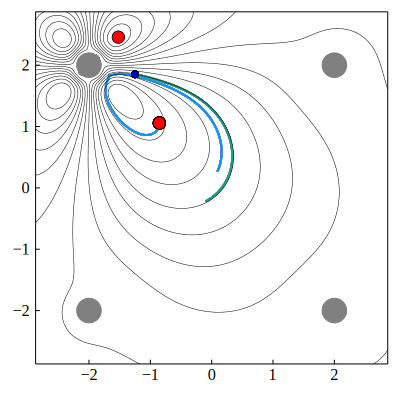

In [42]:
cutoff = info[1][1]
ps = nothing
colours = [i <= n_large_particles ? :red : :blue for i in 1:(n_large_particles + n_small_particles)]
for i in 1:n_particles
    if i == 1
        ps = plot(
            px[i][1:cutoff], py[i][1:cutoff],
            ratio=1,
            legend=false,
            linewidth=2,
            xlim=xlim,
            ylim=ylim,
            tickfont=font(10,"Times"),
            size=(400,400)
        )
    else
        plot!(ps, px[i][1:cutoff], py[i][1:cutoff], linewidth=2)
    end

    scatter!(ps, [px[i][cutoff]], [py[i][cutoff]], markersize=marker_sizes[i], markercolor = colours[i])
end
if !isnothing(drop_row)
    for i in length(keys(drop_row))   
        plot!(ps, px_d_sep[i][1:cutoff], py_d_sep[i][1:cutoff], linewidth=1)
        scatter!(ps, [px_d_sep[i][cutoff]], [py_d_sep[i][cutoff]], markersize=marker_sizes_dropped[i], markercolor = colours_dropped[i])
    end
end

plot!(ps,lagrangian_mean_streamfunction(soln_1),soln_1.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
savefig(ps, "mpart_sep_two_s_2_1.png")


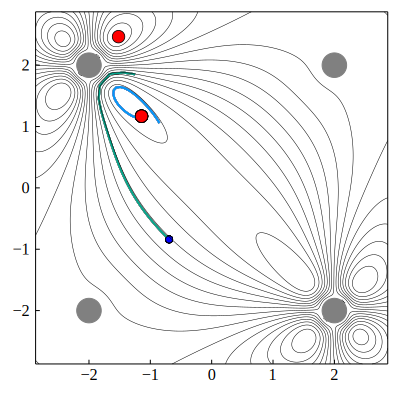

In [43]:
cutoff_2 = info[2][1]
ps = nothing
for i in 1:n_particles
    if i == 1
        ps = plot(
            px[i][cutoff:cutoff_2], py[i][cutoff:cutoff_2],
            ratio=1,
            legend=false,
            linewidth=2,
            xlim=xlim,
            ylim=ylim,
            tickfont=font(10,"Times"),
            size=(400,400)
        )
    else
        plot!(ps, px[i][cutoff:cutoff_2], py[i][cutoff:cutoff_2], linewidth=2)
    end

    scatter!(ps, [px[i][cutoff_2]], [py[i][cutoff_2]], markersize=marker_sizes[i], markercolor = colours[i])
end

if !isnothing(drop_row)
    for i in length(keys(drop_row))   
        plot!(ps, px_d_sep[i][cutoff:cutoff_2], py_d_sep[i][cutoff:cutoff_2], linewidth=1)
        scatter!(ps, [px_d_sep[i][cutoff_2]], [py_d_sep[i][cutoff_2]], markersize=marker_sizes_dropped[i], markercolor = colours_dropped[i])
    end
end


plot!(ps,lagrangian_mean_streamfunction(soln_2),soln_2.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
savefig(ps, "mpart_sep_twos_2_2.png")

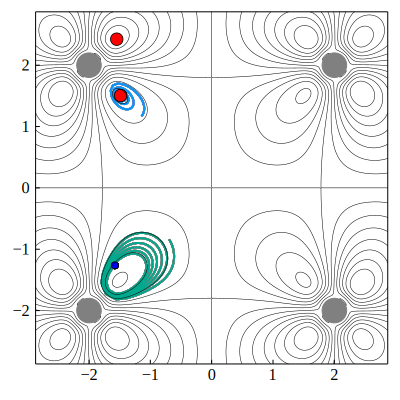

In [44]:
ps = nothing
for i in 1:n_particles
    if i == 1
        ps = plot(
            px[i][cutoff_2:end], py[i][cutoff_2:end],
            ratio=1,
            legend=false,
            linewidth=2,
            xlim=xlim,
            ylim=ylim,
            tickfont=font(10,"Times"),
            size=(400,400)
        )
    else
        plot!(ps, px[i][cutoff_2:end], py[i][cutoff_2:end], linewidth=2)
    end

    scatter!(ps, [px[i][end]], [py[i][end]], markersize=marker_sizes[i], markercolor = colours[i])
end

if !isnothing(drop_row)
    for i in length(keys(drop_row))   
        plot!(ps, px_d_sep[i][cutoff_2:end], py_d_sep[i][cutoff_2:end], linewidth=1)
        scatter!(ps, [px_d_sep[i][end]], [py_d_sep[i][end]], markersize=marker_sizes_dropped[i], markercolor = colours_dropped[i])
    end
end


plot!(ps,lagrangian_mean_streamfunction(soln_3),soln_3.g,levels=15,color=:black,linewidth=0.5)
plot!(ps,bl,fillcolor=:gray,linecolor=:gray)
display(ps)
savefig(ps, "mpart_sep_two_s_2_3.png")